In [ ]:
import sys, pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    RocCurveDisplay,
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [2]:
with open("../data/data.pkl", "rb") as f:
    data = pickle.load(f)

X_train      = data["X_train"]
X_test       = data["X_test"]
y_train      = data["y_train"]
y_test       = data["y_test"]
FEATURES     = data["FEATURES"]

In [3]:
lg_params = dict(
    penalty= "l2",
    C= 1.0,
    solver = "lbfgs",
    max_iter = 1000,
    random_state= 42,
)

def make_lr_pipeline():
    return ImbPipeline([
        ("scaler",  StandardScaler()),
        ("smote",   SMOTE(random_state=42, k_neighbors=5)),
        ("model",   LogisticRegression(**lg_params)),
    ])

print(make_lr_pipeline())

Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('model',
                 LogisticRegression(max_iter=1000, penalty='l2',
                                    random_state=42))])


## Psych Questionnaire Features Only

In [4]:
pipe_a = make_lr_pipeline()
pipe_a.fit(X_train[FEATURES["A_psych"]], y_train)

C:\Users\thanh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'


In [5]:
# Predict and evaluate train and test set
y_train_pred = pipe_a.predict(X_train[FEATURES["A_psych"]])
y_test_pred = pipe_a.predict(X_test[FEATURES["A_psych"]])

print("Train Performance:")
print(classification_report(y_train, y_train_pred))
print("Test Performance:")
print(classification_report(y_test, y_test_pred))

Train Performance:
              precision    recall  f1-score   support

           0       0.93      0.75      0.83      7073
           1       0.38      0.73      0.50      1463

    accuracy                           0.75      8536
   macro avg       0.65      0.74      0.66      8536
weighted avg       0.84      0.75      0.77      8536

Test Performance:
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      1769
           1       0.36      0.69      0.47       366

    accuracy                           0.74      2135
   macro avg       0.64      0.72      0.65      2135
weighted avg       0.82      0.74      0.77      2135



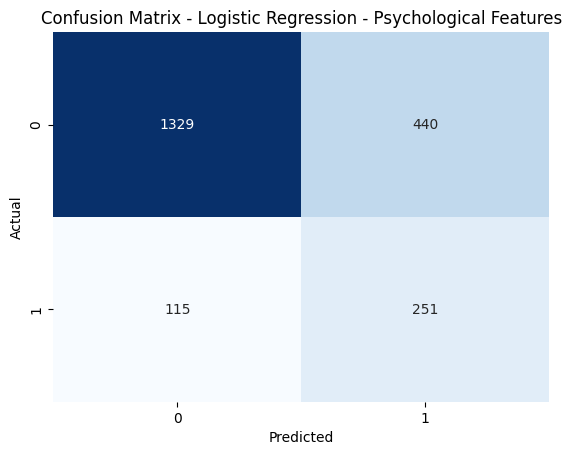

In [6]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression - Psychological Features")
plt.show()

In [ ]:
y_prob_a = pipe_a.predict_proba(X_test[FEATURES["A_psych"]])[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_a):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob_a):.4f}")

In [ ]:
thresholds = np.linspace(0, 1, 101)
f1s, precs, recs = [], [], []
for t in thresholds:
    y_pred_t = (y_prob_a >= t).astype(int)
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    precs.append(precision_score(y_test, y_pred_t, zero_division=0))
    recs.append(recall_score(y_test, y_pred_t, zero_division=0))

best_t = thresholds[np.argmax(f1s)]
plt.figure()
plt.plot(thresholds, f1s, label="F1")
plt.plot(thresholds, precs, label="Precision")
plt.plot(thresholds, recs, label="Recall")
plt.axvline(best_t, color="gray", linestyle="--", label=f"Best t = {best_t:.2f}")
plt.xlabel("Threshold")
plt.title("Threshold Sweep - Psychological Features")
plt.legend()
plt.show()
print(f"Best threshold (max F1): {best_t:.2f}  →  F1 = {max(f1s):.4f}")

In [ ]:
coef = pipe_a.named_steps["model"].coef_[0]
coef_df = (
    pd.DataFrame({"Feature": FEATURES["A_psych"], "Coefficient": coef})
    .assign(abs_coef=lambda d: d["Coefficient"].abs())
    .sort_values("abs_coef", ascending=True)
    .drop(columns="abs_coef")
)
colors = ["#d73027" if c > 0 else "#4575b4" for c in coef_df["Coefficient"]]
fig, ax = plt.subplots(figsize=(7, max(4, len(coef_df) * 0.28)))
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("LR Coefficients - Psychological Features")
plt.tight_layout()
plt.show()

## Gaming Features Only

In [7]:
# Fit model on gaming features only
pipe_b = make_lr_pipeline()
pipe_b.fit(X_train[FEATURES["B_gaming"]], y_train)

C:\Users\thanh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'


In [8]:
# Predict and evaluate train and test set
y_train_pred = pipe_b.predict(X_train[FEATURES["B_gaming"]])
y_test_pred = pipe_b.predict(X_test[FEATURES["B_gaming"]])

print("Train Performance:")
print(classification_report(y_train, y_train_pred))
print("Test Performance:")
print(classification_report(y_test, y_test_pred))

Train Performance:
              precision    recall  f1-score   support

           0       0.88      0.63      0.73      7073
           1       0.24      0.58      0.34      1463

    accuracy                           0.62      8536
   macro avg       0.56      0.60      0.54      8536
weighted avg       0.77      0.62      0.67      8536

Test Performance:
              precision    recall  f1-score   support

           0       0.88      0.64      0.74      1769
           1       0.24      0.56      0.34       366

    accuracy                           0.62      2135
   macro avg       0.56      0.60      0.54      2135
weighted avg       0.77      0.62      0.67      2135



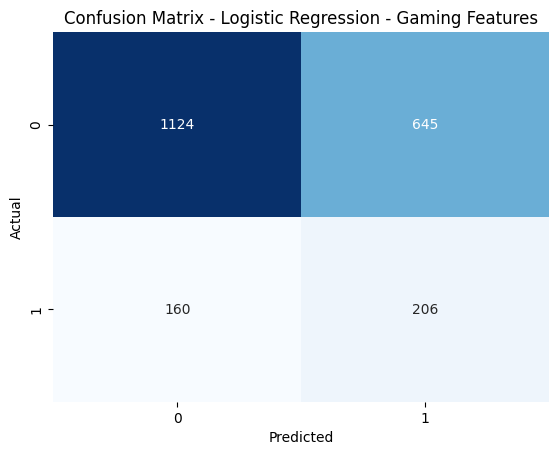

In [9]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression - Gaming Features")
plt.show()

In [ ]:
y_prob_b = pipe_b.predict_proba(X_test[FEATURES["B_gaming"]])[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_b):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob_b):.4f}")

In [ ]:
thresholds = np.linspace(0, 1, 101)
f1s, precs, recs = [], [], []
for t in thresholds:
    y_pred_t = (y_prob_b >= t).astype(int)
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    precs.append(precision_score(y_test, y_pred_t, zero_division=0))
    recs.append(recall_score(y_test, y_pred_t, zero_division=0))

best_t = thresholds[np.argmax(f1s)]
plt.figure()
plt.plot(thresholds, f1s, label="F1")
plt.plot(thresholds, precs, label="Precision")
plt.plot(thresholds, recs, label="Recall")
plt.axvline(best_t, color="gray", linestyle="--", label=f"Best t = {best_t:.2f}")
plt.xlabel("Threshold")
plt.title("Threshold Sweep - Gaming Features")
plt.legend()
plt.show()
print(f"Best threshold (max F1): {best_t:.2f}  →  F1 = {max(f1s):.4f}")

In [ ]:
coef = pipe_b.named_steps["model"].coef_[0]
coef_df = (
    pd.DataFrame({"Feature": FEATURES["B_gaming"], "Coefficient": coef})
    .assign(abs_coef=lambda d: d["Coefficient"].abs())
    .sort_values("abs_coef", ascending=True)
    .drop(columns="abs_coef")
)
colors = ["#d73027" if c > 0 else "#4575b4" for c in coef_df["Coefficient"]]
fig, ax = plt.subplots(figsize=(7, max(4, len(coef_df) * 0.28)))
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("LR Coefficients - Gaming Features")
plt.tight_layout()
plt.show()

## Combined Gaming and Psych Features

In [10]:
# Fit model on gaming features only
pipe_c = make_lr_pipeline()
pipe_c.fit(X_train[FEATURES["C_full"]], y_train)

C:\Users\thanh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'


In [11]:
# Predict and evaluate train and test set
y_train_pred = pipe_c.predict(X_train[FEATURES["C_full"]])
y_test_pred = pipe_c.predict(X_test[FEATURES["C_full"]])

print("Train Performance:")
print(classification_report(y_train, y_train_pred))
print("Test Performance:")
print(classification_report(y_test, y_test_pred))

Train Performance:
              precision    recall  f1-score   support

           0       0.93      0.75      0.83      7073
           1       0.38      0.73      0.50      1463

    accuracy                           0.75      8536
   macro avg       0.66      0.74      0.67      8536
weighted avg       0.84      0.75      0.78      8536

Test Performance:
              precision    recall  f1-score   support

           0       0.93      0.76      0.83      1769
           1       0.38      0.70      0.49       366

    accuracy                           0.75      2135
   macro avg       0.65      0.73      0.66      2135
weighted avg       0.83      0.75      0.78      2135



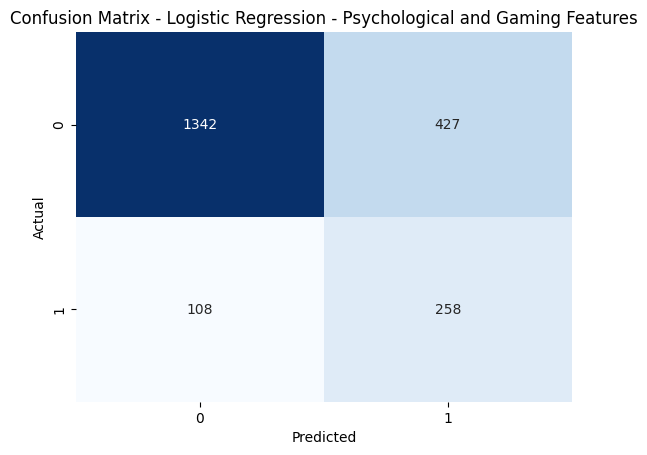

In [12]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression - Psychological and Gaming Features")
plt.show()

In [ ]:
y_prob_c = pipe_c.predict_proba(X_test[FEATURES["C_full"]])[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_c):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob_c):.4f}")

In [ ]:
thresholds = np.linspace(0, 1, 101)
f1s, precs, recs = [], [], []
for t in thresholds:
    y_pred_t = (y_prob_c >= t).astype(int)
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    precs.append(precision_score(y_test, y_pred_t, zero_division=0))
    recs.append(recall_score(y_test, y_pred_t, zero_division=0))

best_t = thresholds[np.argmax(f1s)]
plt.figure()
plt.plot(thresholds, f1s, label="F1")
plt.plot(thresholds, precs, label="Precision")
plt.plot(thresholds, recs, label="Recall")
plt.axvline(best_t, color="gray", linestyle="--", label=f"Best t = {best_t:.2f}")
plt.xlabel("Threshold")
plt.title("Threshold Sweep - Psychological and Gaming Features")
plt.legend()
plt.show()
print(f"Best threshold (max F1): {best_t:.2f}  →  F1 = {max(f1s):.4f}")

In [ ]:
coef = pipe_c.named_steps["model"].coef_[0]
coef_df = (
    pd.DataFrame({"Feature": FEATURES["C_full"], "Coefficient": coef})
    .assign(abs_coef=lambda d: d["Coefficient"].abs())
    .sort_values("abs_coef", ascending=True)
    .drop(columns="abs_coef")
)
colors = ["#d73027" if c > 0 else "#4575b4" for c in coef_df["Coefficient"]]
fig, ax = plt.subplots(figsize=(7, max(4, len(coef_df) * 0.28)))
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("LR Coefficients - Psychological and Gaming Features")
plt.tight_layout()
plt.show()